# 📊 Dusha и RESD — исследование корпусов

Разведочный анализ двух речевых корпусов проекта для распознавания эмоций:

* **Dusha (crowd)** — актёрская («acted») русская речь, размеченная краудсорсерами. В этом ноутбуке используем **агрегированные** данные: голоса нескольких разметчиков на запись схлопнуты алгоритмом Dawid-Skene (порог вероятности 0.9), поэтому **одна строка = одна аудиозапись** с итоговой меткой `emotion`.
* **RESD (Aniemore)** — сыгранные русские диалоги; итоговая метка извлечена из имени клипа (маппинг `happiness→positive`, `anger→angry`, `sadness→sad`, исходные классы `disgust`, `fear`, `enthusiasm` отфильтрованы).

**Файлы:**

| Корпус | Файл | Записей |
|---|---|---|
| Dusha/crowd, train | `processed_dataset_090/aggregated_dataset/crowd_train.jsonl` | 148 547 |
| Dusha/crowd, test | `processed_dataset_090/aggregated_dataset/crowd_test.jsonl` | 13 859 |
| RESD, train | `hug_dataset/data/raw_train-00000-of-00001-1f5fe73d1293189c.jsonl` | 916 |
| RESD, test | `hug_dataset/data/raw_test-00000-of-00001-a2b788d59856c4ae.jsonl` | 224 |

**Схема Dusha/crowd:**

| Поле | Описание |
|---|---|
| `hash_id` | уникальный идентификатор записи (= имя wav-файла) |
| `audio_path` | путь к аудио |
| `duration` | длительность записи, секунды |
| `emotion` | итоговая агрегированная метка: `neutral`, `sad`, `angry`, `positive`, `other` |
| `speaker_text` | транскрипт реплики (ASR), есть пропуски (~1% в train) |
| `speaker_emo` | эмоция, заявленная самим диктором, 4 класса |
| `source_id` | идентификатор диалога-исходника |

**Схема RESD (raw-файлы):**

| Поле | Описание |
|---|---|
| `hash_id` | идентификатор вида `32_happiness_enthusiasm_h_120`: номер серии + две исходные метки RESD + буква класса + индекс |
| `audio_path` | путь к аудио |
| `duration` | длительность записи, секунды |
| `annotator_emo` | **итоговая метка** (4 класса), извлечена из имени клипа при конвертации датасета |
| `annotator_id` | техническая константа `ext_annotator_1`, живых аннотаторов у файла нет |
| `speaker_text` | транскрипт реплики |
| `speaker_emo` | копия `annotator_emo`: оба поля заполняются из одного значения при сборке файла |
| `source_id` | пуст во всех строках |

> Пути к данным берутся **из конфига** `ruintona/my_experiments/data.json` (ключ `base_path`) через `config_utils.get_dataset_path()`.

> Корпуса анализируются **отдельно и последовательно**: сначала Dusha/crowd, затем RESD.

In [ ]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "ruintona" / "my_experiments").is_dir():
            return candidate
    raise RuntimeError("Корень репозитория не найден")


sys.path.insert(0, str(find_project_root()))
from ruintona.my_experiments.utils.config_utils import get_dataset_path  # noqa: E402

BASE = get_dataset_path()
CROWD_TRAIN_PATH = BASE / "processed_dataset_090" / "aggregated_dataset" / "crowd_train.jsonl"
CROWD_TEST_PATH = BASE / "processed_dataset_090" / "aggregated_dataset" / "crowd_test.jsonl"
RESD_TRAIN_PATH = BASE / "hug_dataset" / "data" / "raw_train-00000-of-00001-1f5fe73d1293189c.jsonl"
RESD_TEST_PATH = BASE / "hug_dataset" / "data" / "raw_test-00000-of-00001-a2b788d59856c4ae.jsonl"
print("base_path из data.json:", BASE)

CROWD_COLS = ["hash_id", "audio_path", "duration", "emotion", "speaker_text", "speaker_emo", "source_id"]
RESD_COLS = ["hash_id", "audio_path", "duration", "annotator_emo",
             "speaker_text", "speaker_emo", "source_id"]

EMO_ORDER_CROWD = ["neutral", "sad", "angry", "positive", "other"]
EMO_ORDER_SELF = ["neutral", "sad", "angry", "positive"]
EMO_ORDER_RESD = ["positive", "sad", "angry", "neutral"]


def load_jsonl(path: Path, columns: list[str]) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as file:
        for line in file:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)[columns]


def plot_category_distribution(dfs, titles, order, column="emotion"):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6 * len(dfs), 4))
    axes = np.atleast_1d(axes)
    for ax, df, title in zip(axes, dfs, titles):
        counts = df[column].value_counts().reindex(order).fillna(0).astype(int)
        bars = ax.bar(counts.index, counts.values, color=sns.color_palette("crest", len(order)))
        total = int(counts.sum())
        ax.bar_label(bars, labels=[f"{v:,}\n{v / total:.1%}".replace(",", " ") for v in counts.values], fontsize=9)
        ax.set_title(f"{title}: {column}")
        ax.set_ylabel("число записей")
        ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()


def plot_durations(dfs, titles):
    fig, axes = plt.subplots(1, len(dfs), figsize=(6 * len(dfs), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, df, title in zip(axes, dfs, titles):
        ax.hist(df["duration"], bins=50, color="#4c72b0")
        ax.axvline(df["duration"].median(), color="#c44e52", linestyle="--",
                   label=f"медиана = {df['duration'].median():.1f} с")
        ax.set_title(title)
        ax.set_xlabel("длительность, с")
        ax.legend()
    axes[0].set_ylabel("число записей")
    plt.tight_layout()
    plt.show()


def collect_tokens(text_series) -> Counter:
    tokens = Counter()
    for text in text_series.dropna():
        tokens.update(re.findall(r"[а-яёa-z]+", str(text).lower()))
    return tokens


def norm_text(value) -> str:
    return re.sub(r"\s+", " ", str(value).strip().lower())


def overlap_table(pairs) -> pd.DataFrame:
    rows = []
    for label, left, right in pairs:
        intersection = left & right
        rows.append({
            "прокси": label,
            "пересечение": len(intersection),
            "% от train": round(100 * len(intersection) / max(len(left), 1), 2),
            "% от test": round(100 * len(intersection) / max(len(right), 1), 2),
        })
    return pd.DataFrame(rows)


def plot_overlap(table: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.barh(table["прокси"], table["% от test"], color="#dd8452")
    ax.bar_label(bars, fmt="%.2f%%")
    ax.set_xlim(0, max(100, table["% от test"].max() * 1.15))
    ax.set_title(title)
    ax.set_xlabel("% от test")
    plt.tight_layout()
    plt.show()

---
## Часть I — Dusha/crowd

### I.1 Загрузка данных

Читаем JSONL построчно и собираем DataFrame. В агрегированных файлах каждая строка — уже готовая запись с финальной меткой, поэтому дедупликация не требуется.

In [7]:
crowd_train = load_jsonl(CROWD_TRAIN_PATH, CROWD_COLS)
crowd_test = load_jsonl(CROWD_TEST_PATH, CROWD_COLS)
print("crowd_train:", crowd_train.shape)
print("crowd_test: ", crowd_test.shape)
crowd_train.head()

crowd_train: (148547, 7)
crowd_test:  (13859, 7)


,hash_id,audio_path,duration,emotion,speaker_text,speaker_emo,source_id
0,475e76f77ac1ed7cabafca740b15b32a,crowd_train/wavs/475e76f77ac1ed7cabafca740b15b...,2.453000,angry,не надо не надо не надо не надо,angry,fa136da095807ea6cd18dd6e2f58d4d0
1,2f9438ef68395c70a8714dc373a49d11,crowd_train/wavs/2f9438ef68395c70a8714dc373a49...,4.640000,neutral,фозил кори mp три,neutral,3d436884cbbe25373914f8768de494f7
2,9937036a9c0dba20eecbffddd00f2be2,crowd_train/wavs/9937036a9c0dba20eecbffddd00f2...,4.341750,neutral,NaN,NaN,NaN
3,fb0ae78586a235018103acec22a80a8f,crowd_train/wavs/fb0ae78586a235018103acec22a80...,3.900562,neutral,сколько стоит на керамбит,neutral,80bc833cf6b3f106d2e8991783a31e2b
4,196dcf9e1aaac46c2aee45e7f6adfb92,crowd_train/wavs/196dcf9e1aaac46c2aee45e7f6adf...,4.780000,neutral,афина когда закончится эта телепередача,neutral,bd78f079676fa5f1ed17253c9a440cc6


In [8]:
crowd_train.info()

pd.DataFrame({
    "пропусков в train, %": crowd_train.isna().mean().mul(100).round(2),
    "пропусков в test, %": crowd_test.isna().mean().mul(100).round(2),
})

<class 'pandas.DataFrame'>
RangeIndex: 148547 entries, 0 to 148546
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   hash_id       148547 non-null  str    
 1   audio_path    148547 non-null  str    
 2   duration      148547 non-null  float64
 3   emotion       148547 non-null  str    
 4   speaker_text  147022 non-null  str    
 5   speaker_emo   147022 non-null  str    
 6   source_id     147022 non-null  str    
dtypes: float64(1), str(6)
memory usage: 32.3 MB


,"пропусков в train, %","пропусков в test, %"
hash_id,0.00,0.0
audio_path,0.00,0.0
duration,0.00,0.0
emotion,0.00,0.0
speaker_text,1.03,0.0
speaker_emo,1.03,0.0
source_id,1.03,0.0


### I.2 Распределение по эмоциям

`emotion` — итоговая метка после агрегации голосов разметчиков, `speaker_emo` — эмоция, которую заявил сам диктор. Смотрим распределения обоих признаков и их согласованность.

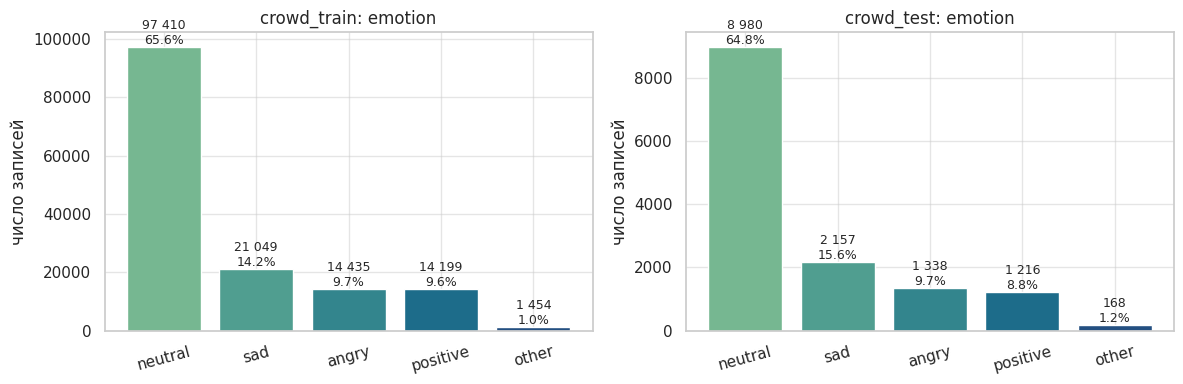

In [9]:
plot_category_distribution([crowd_train, crowd_test],
                           ["crowd_train", "crowd_test"],
                           EMO_ORDER_CROWD, column="emotion")

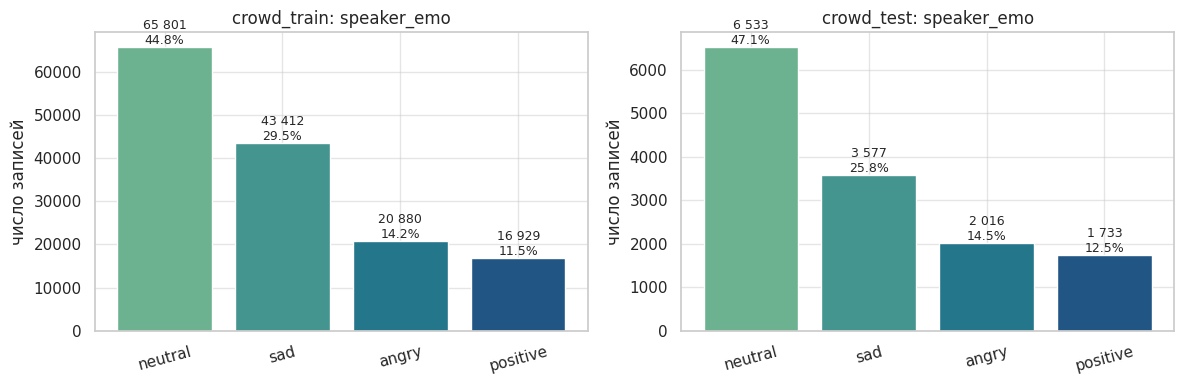

In [10]:
plot_category_distribution([crowd_train, crowd_test],
                           ["crowd_train", "crowd_test"],
                           EMO_ORDER_SELF, column="speaker_emo")

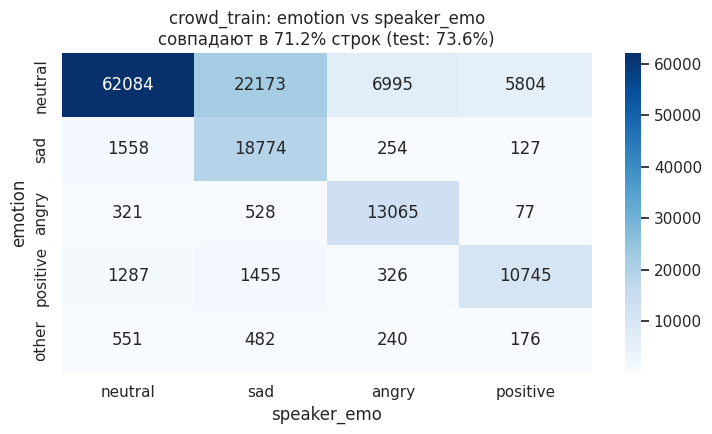

In [11]:
crowd_train_agree = crowd_train.dropna(subset=["speaker_emo"])
crowd_test_agree = crowd_test.dropna(subset=["speaker_emo"])
match_train = (crowd_train_agree["emotion"] == crowd_train_agree["speaker_emo"]).mean()
match_test = (crowd_test_agree["emotion"] == crowd_test_agree["speaker_emo"]).mean()

confusion = pd.crosstab(crowd_train_agree["emotion"], crowd_train_agree["speaker_emo"])
confusion = confusion.reindex(index=EMO_ORDER_CROWD, columns=EMO_ORDER_SELF, fill_value=0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"crowd_train: emotion vs speaker_emo\nсовпадают в {match_train:.1%} строк (test: {match_test:.1%})")
ax.set_xlabel("speaker_emo")
ax.set_ylabel("emotion")
plt.tight_layout()
plt.show()

### I.3 Длительность аудио

Смотрим форму распределения, медиану и разброс внутри каждой эмоции.

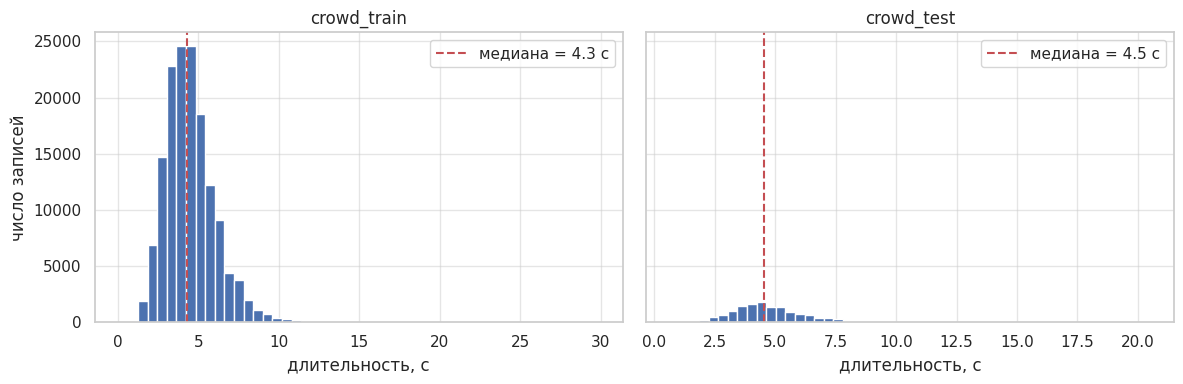

,count,mean,std,min,25%,50%,75%,max
duration,148547.0,4.52,1.61,0.06,3.42,4.3,5.34,29.88


In [12]:
plot_durations([crowd_train, crowd_test], ["crowd_train", "crowd_test"])

crowd_train[["duration"]].describe().T.round(2)

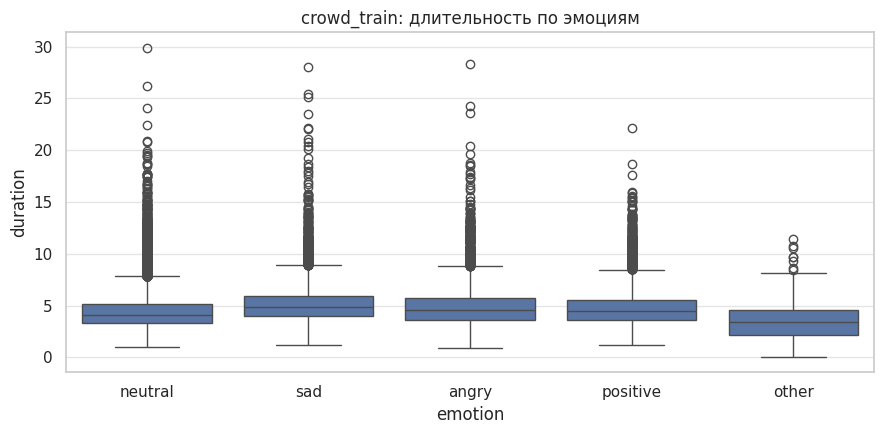

,count,mean,median,min,max
emotion,,,,,
angry,14435,4.85,4.56,0.95,28.28
neutral,97410,4.32,4.14,1.02,29.88
other,1454,3.44,3.39,0.06,11.40
positive,14199,4.73,4.48,1.17,22.15
sad,21049,5.10,4.88,1.22,28.02


In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=crowd_train, x="emotion", y="duration", order=EMO_ORDER_CROWD, ax=ax)
ax.set_title("crowd_train: длительность по эмоциям")
plt.tight_layout()
plt.show()

crowd_train.groupby("emotion")["duration"].agg(["count", "mean", "median", "min", "max"]).round(2)

### I.4 Тексты (`speaker_text`)

Оцениваем длину реплик, долю пропусков и самые частые слова. Стоп-слова специально не убираем — это «честная» частотность сырых транскриптов.

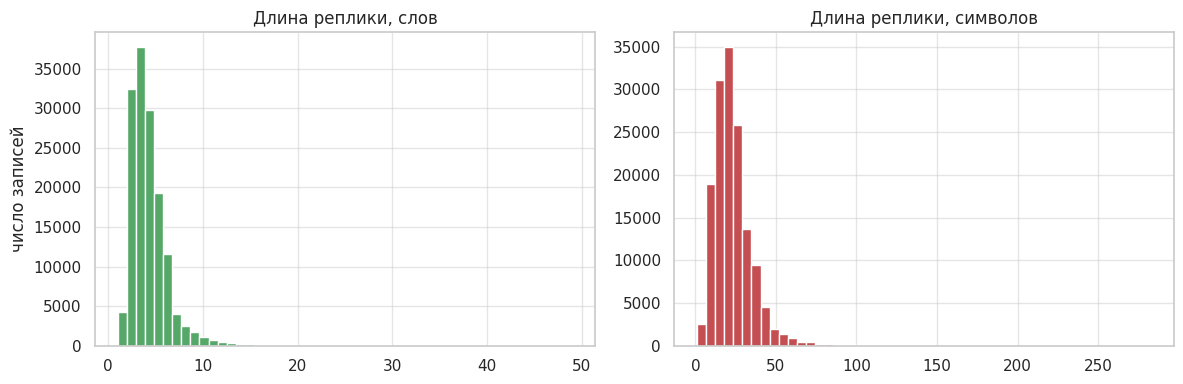

Пропусков speaker_text в train: 1525 (1.0%), в test: 0
Медиана: 3 слов / 21 символов


In [14]:
word_len = crowd_train["speaker_text"].str.split().str.len()
char_len = crowd_train["speaker_text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(word_len.dropna(), bins=50, color="#55a868")
axes[0].set_title("Длина реплики, слов")
axes[1].hist(char_len.dropna(), bins=50, color="#c44e52")
axes[1].set_title("Длина реплики, символов")
axes[0].set_ylabel("число записей")
plt.tight_layout()
plt.show()

print(f"Пропусков speaker_text в train: {crowd_train['speaker_text'].isna().sum()} "
      f"({crowd_train['speaker_text'].isna().mean():.1%}), в test: {crowd_test['speaker_text'].isna().sum()}")
print(f"Медиана: {word_len.median():.0f} слов / {char_len.median():.0f} символов")

,пример реплики
emotion,
angry,не надо не надо не надо не надо
neutral,фозил кори mp три
other,кучина все альбомы сделай
positive,не за что сбер ты крутой
sad,конечно надо


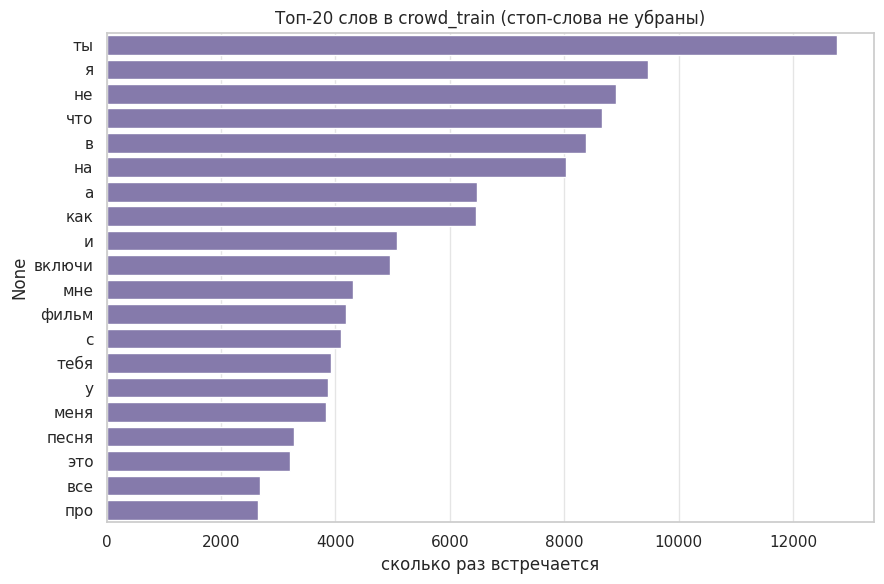

In [15]:
examples = crowd_train.dropna(subset=["speaker_text"]).groupby("emotion")["speaker_text"].first()
display(examples.to_frame("пример реплики"))

top_words = pd.Series(dict(collect_tokens(crowd_train["speaker_text"]).most_common(20)), name="частота")
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_words.values, y=top_words.index, color="#8172b3", ax=ax)
ax.set_title("Топ-20 слов в crowd_train (стоп-слова не убраны)")
ax.set_xlabel("сколько раз встречается")
plt.tight_layout()
plt.show()

### I.5 Источники (`source_id`)

`source_id` — это диалог, из которого вырезан клип. Все клипы одного источника почти наверняка принадлежат одному диктору, поэтому этот столбец — наш главный «прокси спикера».

Уникальных источников: train = 1876, test = 190
Клипов на источник (train): медиана = 67, максимум = 508 (749bd4cad1dd…)


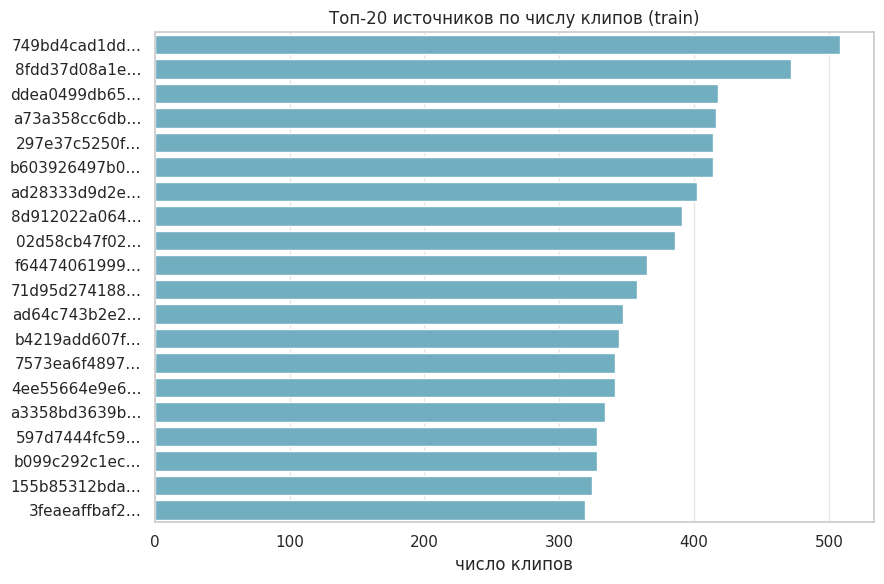

In [16]:
src_train = crowd_train["source_id"].value_counts()
src_test = crowd_test["source_id"].value_counts()
print(f"Уникальных источников: train = {src_train.size}, test = {src_test.size}")
print(f"Клипов на источник (train): медиана = {src_train.median():.0f}, "
      f"максимум = {src_train.max()} ({src_train.index[0][:12]}…)")

fig, ax = plt.subplots(figsize=(9, 6))
top_src = src_train.head(20)
sns.barplot(x=top_src.values, y=[s[:12] + "…" for s in top_src.index], color="#64b5cd", ax=ax)
ax.set_title("Топ-20 источников по числу клипов (train)")
ax.set_xlabel("число клипов")
plt.tight_layout()
plt.show()

### I.6 Пересечения между train и test (проверка утечек)

> ⚠️ **Уточнение про спикеров.** В исходных датасетах **нет данных о спикерах**: поля `speaker_id` в файлах не существует, а `speaker_text` и `speaker_emo` описывают реплику и заявленную эмоцию, но не личность человека (в документации `DUSHA.md` спикеры упоминаются лишь как сводная метрика датасета). Поэтому пересечение «по спикерам» можно оценить **только предположительно** — через прокси:
>
> * `hash_id` — дубликаты самих записей;
> * `source_id` — клипы одного источника ⇒ почти наверняка один диктор;
> * нормализованные тексты — точные дубликаты реплик.

Считаем пересечения множеств между train и test.

,прокси,пересечение,% от train,% от test
0,hash_id (записи),0,0.00,0.00
1,source_id (диалоги),0,0.00,0.00
2,нормализованные тексты,6615,6.02,49.11


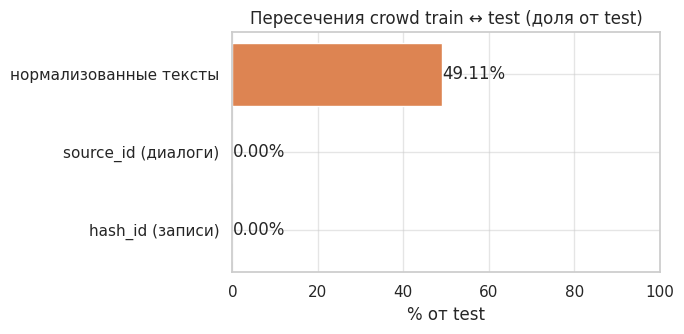

In [17]:
hash_overlap = set(crowd_train["hash_id"]) & set(crowd_test["hash_id"])
source_overlap = set(crowd_train["source_id"].dropna()) & set(crowd_test["source_id"].dropna())
text_overlap = (set(crowd_train["speaker_text"].dropna().map(norm_text))
                & set(crowd_test["speaker_text"].dropna().map(norm_text)))

crowd_leaks = overlap_table([
    ("hash_id (записи)", set(crowd_train["hash_id"]), set(crowd_test["hash_id"])),
    ("source_id (диалоги)", set(crowd_train["source_id"].dropna()), set(crowd_test["source_id"].dropna())),
    ("нормализованные тексты",
     set(crowd_train["speaker_text"].dropna().map(norm_text)),
     set(crowd_test["speaker_text"].dropna().map(norm_text))),
])
display(crowd_leaks)
plot_overlap(crowd_leaks, "Пересечения crowd train ↔ test (доля от test)")

#### Примеры записей с одинаковым нормализованным текстом

Показываем несколько конкретных пар «train ↔ test» с совпадающим текстом: сам текст, `hash_id` и путь к wav обеих сторон.

In [18]:
train_texts = crowd_train.dropna(subset=["speaker_text"]).copy()
train_texts["norm"] = train_texts["speaker_text"].map(norm_text)
test_texts = crowd_test.dropna(subset=["speaker_text"]).copy()
test_texts["norm"] = test_texts["speaker_text"].map(norm_text)

common_norms = sorted(set(train_texts["norm"]) & set(test_texts["norm"]))
print(f"Уникальных текстов в пересечении train↔test: {len(common_norms)} — ниже первые {min(5, len(common_norms))}")

example_rows = []
for norm in common_norms[:5]:
    train_row = train_texts.loc[train_texts["norm"] == norm].iloc[0]
    test_row = test_texts.loc[test_texts["norm"] == norm].iloc[0]
    example_rows.append({
        "текст": train_row["speaker_text"],
        "hash_id (train)": train_row["hash_id"],
        "wav (train)": train_row["audio_path"],
        "hash_id (test)": test_row["hash_id"],
        "wav (test)": test_row["audio_path"],
    })

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(example_rows))

Уникальных текстов в пересечении train↔test: 6615 — ниже первые 5


,текст,hash_id (train),wav (train),hash_id (test),wav (test)
0,2gis брюс ли,79398e1e4f3a03447eab6dc96db82aad,crowd_train/wavs/79398e1e4f3a03447eab6dc96db82aad.wav,40735ec10b02cc824a3b591e066fd4da,crowd_test/wavs/40735ec10b02cc824a3b591e066fd4da.wav
1,all hello,034ad506e95582af275b1012d10dd0ea,crowd_train/wavs/034ad506e95582af275b1012d10dd0ea.wav,a5c9d8a9f93d207a2e8127f8f0e898e1,crowd_test/wavs/a5c9d8a9f93d207a2e8127f8f0e898e1.wav
2,animal джаz лето,efff3eedee80eb4cfd0ed8350ae33429,crowd_train/wavs/efff3eedee80eb4cfd0ed8350ae33429.wav,6476e7f8054851ee03295f991af582ae,crowd_test/wavs/6476e7f8054851ee03295f991af582ae.wav
3,art салон тупой или умный,030bf71e0ecf2bfcd0d9d1dbe5e0479b,crowd_train/wavs/030bf71e0ecf2bfcd0d9d1dbe5e0479b.wav,241e8ea7f3002514adb9a4ca7c7d3eca,crowd_test/wavs/241e8ea7f3002514adb9a4ca7c7d3eca.wav
4,artik и asti ка истеричка,d3b522f309cf51d42c71b729ebe41fcb,crowd_train/wavs/d3b522f309cf51d42c71b729ebe41fcb.wav,d5013cd961ff0e20f7f3f5f90cf793f0,crowd_test/wavs/d5013cd961ff0e20f7f3f5f90cf793f0.wav


### I.7 Выводы по Dusha/crowd

In [19]:
neutr_share = (crowd_train["emotion"] == "neutral").mean()
other_share = (crowd_train["emotion"] == "other").mean()
print(f"Размер: train = {len(crowd_train):,} записей, test = {len(crowd_test):,}".replace(",", " "))
print(f"Дисбаланс: neutral = {neutr_share:.1%} train, редкие angry/positive ≈ по 10%, other = {other_share:.1%}")
print(f"Длительности: медиана {crowd_train['duration'].median():.1f} с, максимум {crowd_train['duration'].max():.1f} с")
print(f"Тексты: медиана {word_len.median():.0f} слов, пропусков {crowd_train['speaker_text'].isna().mean():.1%}")
print(f"Источников: {src_train.size} в train, самый большой — {src_train.max()} клипов")
print(f"Самооценка speaker_emo совпадает с итоговой меткой в {match_train:.1%} строк train")
print(f"Утечки train↔test: записей {len(hash_overlap)}, источников {len(source_overlap)}, текстов {len(text_overlap)}")

Размер: train = 148 547 записей  test = 13 859
Дисбаланс: neutral = 65.6% train, редкие angry/positive ≈ по 10%, other = 1.0%
Длительности: медиана 4.3 с, максимум 29.9 с
Тексты: медиана 3 слов, пропусков 1.0%
Источников: 1876 в train, самый большой — 508 клипов
Самооценка speaker_emo совпадает с итоговой меткой в 71.2% строк train
Утечки train↔test: записей 0, источников 0, текстов 6615


---
## 🎭 Часть II — RESD

### II.1 Загрузка данных

RESD заметно меньше (916 + 224 записи), работаем с **raw-файлами**. Столбца `emotion` в них нет: итоговая метка лежит в `annotator_emo` — она извлечена из имени клипа при конвертации датасета; `speaker_emo` при сборке файла заполнен тем же значением, а `source_id` пуст во всех строках.

In [20]:
resd_train = load_jsonl(RESD_TRAIN_PATH, RESD_COLS)
resd_test = load_jsonl(RESD_TEST_PATH, RESD_COLS)
print("resd_train:", resd_train.shape)
print("resd_test: ", resd_test.shape)
resd_train.head()

resd_train: (916, 7)
resd_test:  (224, 7)


,hash_id,audio_path,duration,annotator_emo,speaker_text,speaker_emo,source_id
0,32_happiness_enthusiasm_h_120,wavs/32_happiness_enthusiasm_h_120.wav,5.138187,positive,"Конечно, расскажу, обязательно. Ой, сейчас рас...",positive,NaN
1,36_disgust_happiness_d_130,wavs/36_disgust_happiness_d_130.wav,2.940562,positive,Вы ещё и профессию решили поменять.,positive,NaN
2,34_anger_fear_a_060,wavs/34_anger_fear_a_060.wav,3.214625,angry,"Ты знаешь, чем это для тебя закончится?",angry,NaN
3,25_anger_disgust_a_010,wavs/25_anger_disgust_a_010.wav,5.120000,angry,Добрый день. Вы хотели бы приобрести недвижимо...,angry,NaN
4,17_neutral_disgust_d_092,wavs/17_neutral_disgust_d_092.wav,5.411678,neutral,"все ваши рекламные акции, пожалуйста, больше н...",neutral,NaN


In [21]:
pd.DataFrame({
    "пропусков в train, %": resd_train.isna().mean().mul(100).round(2),
    "пропусков в test, %": resd_test.isna().mean().mul(100).round(2),
})

,"пропусков в train, %","пропусков в test, %"
hash_id,0.0,0.0
audio_path,0.0,0.0
duration,0.0,0.0
annotator_emo,0.0,0.0
speaker_text,0.0,0.0
speaker_emo,0.0,0.0
source_id,100.0,100.0


### II.2 Распределение по эмоциям

В RESD четыре класса (без `other`); смотрим распределение итоговой метки `annotator_emo`.

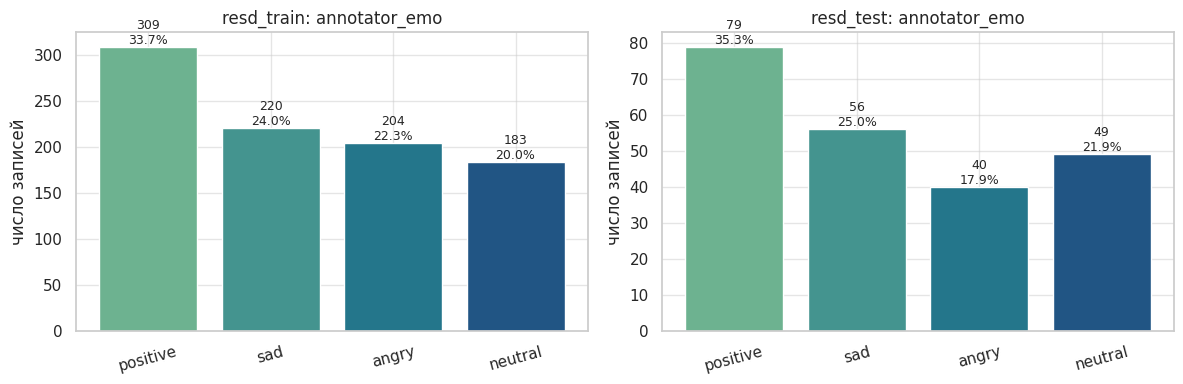

In [22]:
plot_category_distribution([resd_train, resd_test],
                           ["resd_train", "resd_test"],
                           EMO_ORDER_RESD, column="annotator_emo")

### II.3 Длительность аудио

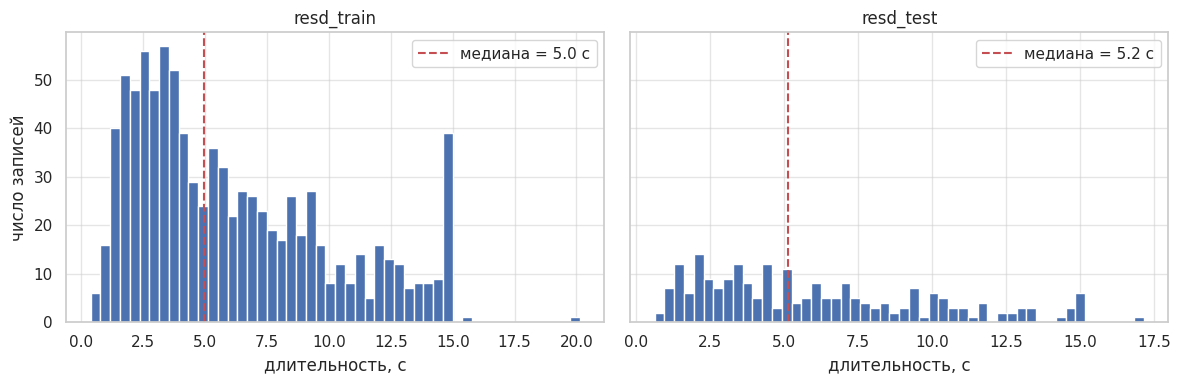

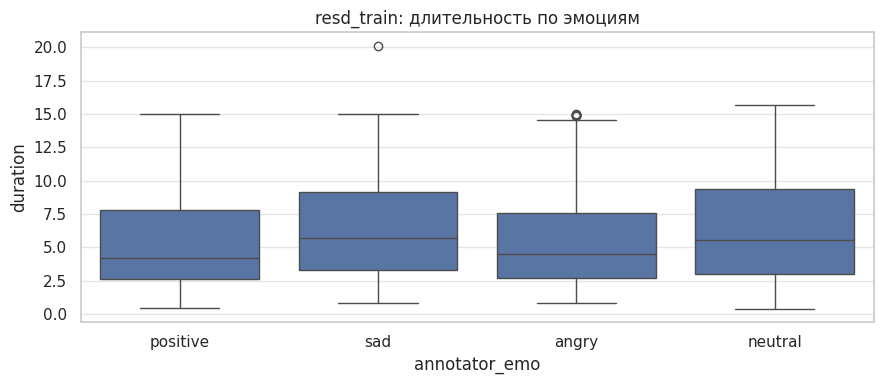

,count,mean,median,min,max
annotator_emo,,,,,
angry,204,5.57,4.50,0.79,14.98
neutral,183,6.54,5.54,0.37,15.70
positive,309,5.56,4.22,0.45,15.00
sad,220,6.67,5.71,0.82,20.14


In [23]:
plot_durations([resd_train, resd_test], ["resd_train", "resd_test"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=resd_train, x="annotator_emo", y="duration", order=EMO_ORDER_RESD, ax=ax)
ax.set_title("resd_train: длительность по эмоциям")
ax.set_xlabel("annotator_emo")
plt.tight_layout()
plt.show()

resd_train.groupby("annotator_emo")["duration"].agg(["count", "mean", "median", "min", "max"]).round(2)

### II.4 Тексты (`speaker_text`)

В отличие от Dusha, здесь транскрипты без пропусков и в среднем заметно длиннее — реплики спонтанных диалогов.

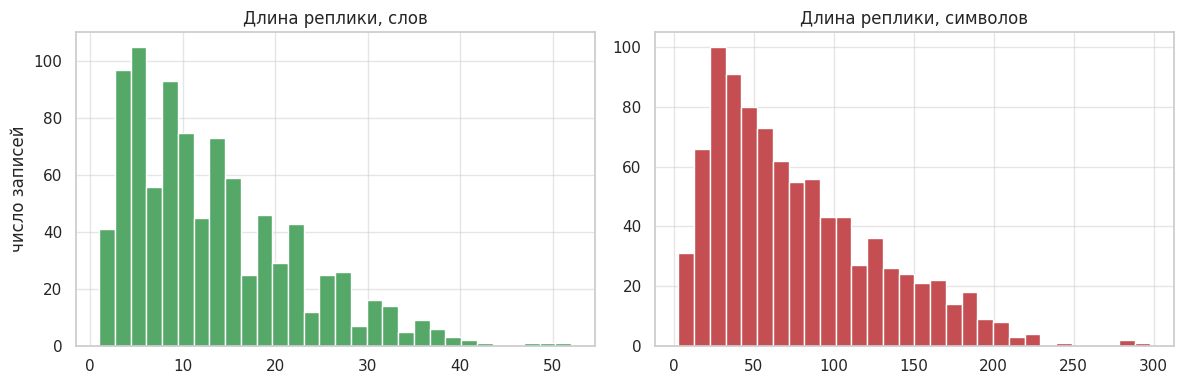

Медиана: 11 слов / 64 символов


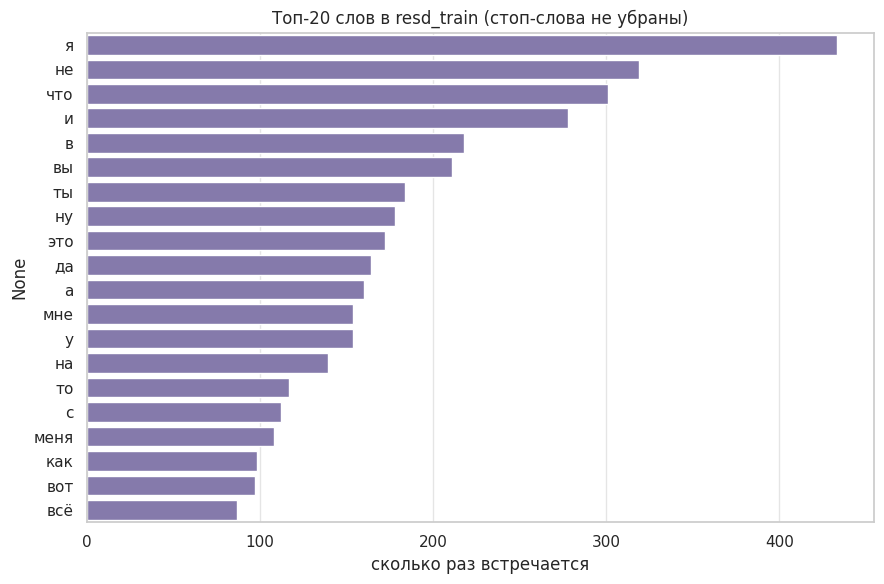

In [24]:
resd_word_len = resd_train["speaker_text"].str.split().str.len()
resd_char_len = resd_train["speaker_text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(resd_word_len, bins=30, color="#55a868")
axes[0].set_title("Длина реплики, слов")
axes[1].hist(resd_char_len, bins=30, color="#c44e52")
axes[1].set_title("Длина реплики, символов")
axes[0].set_ylabel("число записей")
plt.tight_layout()
plt.show()

print(f"Медиана: {resd_word_len.median():.0f} слов / {resd_char_len.median():.0f} символов")

resd_top_words = pd.Series(dict(collect_tokens(resd_train["speaker_text"]).most_common(20)), name="частота")
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=resd_top_words.values, y=resd_top_words.index, color="#8172b3", ax=ax)
ax.set_title("Топ-20 слов в resd_train (стоп-слова не убраны)")
ax.set_xlabel("сколько раз встречается")
plt.tight_layout()
plt.show()

### II.5 Группы записей по префиксу `hash_id`

`source_id` в RESD пуст, поэтому единственный возможный прокси «источника/спикерской группы» — числовой префикс `hash_id` вида `32_happiness_enthusiasm_h_120`. По документации RESD записывали пары актёров, поэтому префикс, вероятно, кодирует пару/диалог. Это **гипотеза**, а не факт из данных.

Уникальных префиксов: train = 41, test = 41
Клипов на префикс (train): медиана = 24, максимум = 37


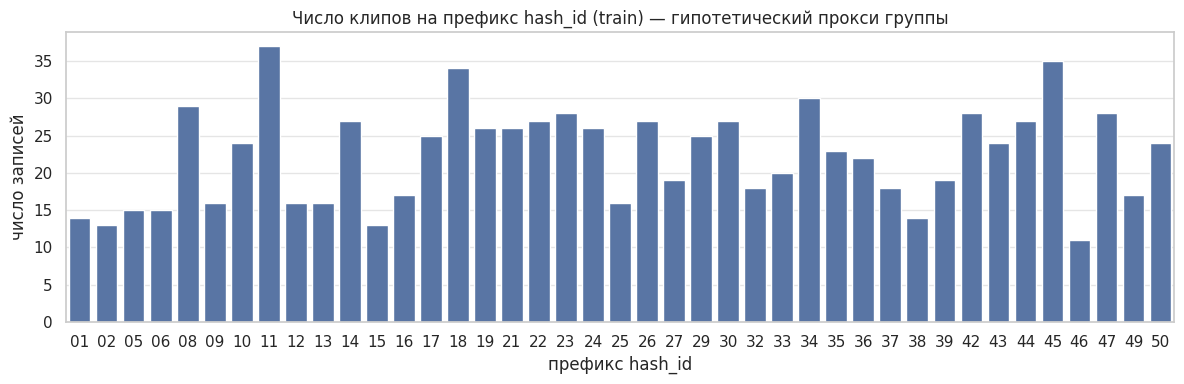

In [25]:
resd_train = resd_train.assign(prefix=resd_train["hash_id"].str.split("_").str[0])
resd_test = resd_test.assign(prefix=resd_test["hash_id"].str.split("_").str[0])

pref_counts = resd_train["prefix"].value_counts().sort_index()
print(f"Уникальных префиксов: train = {pref_counts.size}, test = {resd_test['prefix'].nunique()}")
print(f"Клипов на префикс (train): медиана = {pref_counts.median():.0f}, максимум = {pref_counts.max()}")

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=pref_counts.index, y=pref_counts.values, color="#4c72b0", ax=ax)
ax.set_title("Число клипов на префикс hash_id (train) — гипотетический прокси группы")
ax.set_xlabel("префикс hash_id")
ax.set_ylabel("число записей")
plt.tight_layout()
plt.show()

### II.6 Пересечения между train и test (проверка утечек)

Как и для Dusha: **реальных данных о спикерах в датасете нет**, поэтому проверяем пересечения по доступным прокси — записям (`hash_id`), текстам и гипотетическим группам (префикс `hash_id`).

,прокси,пересечение,% от train,% от test
0,hash_id (записи),0,0.00,0.00
1,нормализованные тексты,2,0.22,0.89
2,префикс hash_id (гипотеза),41,100.00,100.00


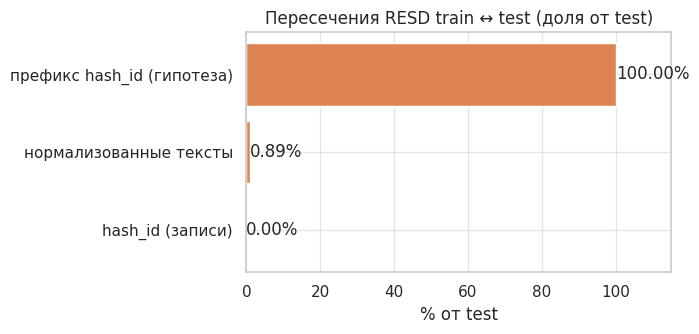

Повторяющихся текстов внутри resd_train: 3


In [26]:
resd_leaks = overlap_table([
    ("hash_id (записи)", set(resd_train["hash_id"]), set(resd_test["hash_id"])),
    ("нормализованные тексты",
     set(resd_train["speaker_text"].dropna().map(norm_text)),
     set(resd_test["speaker_text"].dropna().map(norm_text))),
    ("префикс hash_id (гипотеза)", set(resd_train["prefix"]), set(resd_test["prefix"])),
])
display(resd_leaks)
plot_overlap(resd_leaks, "Пересечения RESD train ↔ test (доля от test)")

text_dupes_train = len(resd_train) - resd_train["speaker_text"].map(norm_text).nunique()
print(f"Повторяющихся текстов внутри resd_train: {text_dupes_train}")

### II.7 Выводы по RESD

In [27]:
pos_share = (resd_train["annotator_emo"] == "positive").mean()
neutr_share_resd = (resd_train["annotator_emo"] == "neutral").mean()
print(f"Размер: train = {len(resd_train)} записей, test = {len(resd_test)} — в ~160 раз меньше crowd_train")
print(f"Дисбаланс мягче, чем у crowd: positive = {pos_share:.1%}, neutral = {neutr_share_resd:.1%}")
print(f"Длительности: медиана {resd_train['duration'].median():.1f} с — сопоставимо с crowd")
print(f"Тексты длиннее: медиана {resd_word_len.median():.0f} слов против {word_len.median():.0f} у crowd")
print(f"Утечки train↔test: записей {resd_leaks.loc[0, 'пересечение']}, "
      f"текстов {resd_leaks.loc[1, 'пересечение']}, групп-префиксов {resd_leaks.loc[2, 'пересечение']}")

Размер: train = 916 записей, test = 224 — в ~160 раз меньше crowd_train
Дисбаланс мягче, чем у crowd: positive = 33.7%, neutral = 20.0%
Длительности: медиана 5.0 с — сопоставимо с crowd
Тексты длиннее: медиана 11 слов против 3 у crowd
Утечки train↔test: записей 0, текстов 2, групп-префиксов 41


---
## 🧾 Итоговая сводка

Собираем ключевые метрики обоих корпусов в одну таблицу (корпуса по-прежнему не сравниваем «в лоб» — таблица лишь фиксирует характеристики каждого).

In [28]:
summary = pd.DataFrame([
    {
        "корпус": "Dusha/crowd",
        "train": len(crowd_train),
        "test": len(crowd_test),
        "классы": ", ".join(EMO_ORDER_CROWD),
        "топ-класс (train)": f"neutral — {neutr_share:.1%}",
        "медианная длительность, с": round(crowd_train["duration"].median(), 1),
        "медианный текст, слов": int(word_len.median()),
        "прокси источника": f"{src_train.size} source_id",
        "дубли записей train↔test": len(hash_overlap),
        "дубли текстов train↔test": len(text_overlap),
    },
    {
        "корпус": "RESD",
        "train": len(resd_train),
        "test": len(resd_test),
        "классы": ", ".join(EMO_ORDER_RESD),
        "топ-класс (train)": f"positive — {pos_share:.1%}",
        "медианная длительность, с": round(resd_train["duration"].median(), 1),
        "медианный текст, слов": int(resd_word_len.median()),
        "прокси источника": f"{pref_counts.size} префиксов hash_id (гипотеза)",
        "дубли записей train↔test": int(resd_leaks.loc[0, "пересечение"]),
        "дубли текстов train↔test": int(resd_leaks.loc[1, "пересечение"]),
    },
]).T
summary

,0,1
корпус,Dusha/crowd,RESD
train,148547,916
test,13859,224
классы,"neutral, sad, angry, positive, other","positive, sad, angry, neutral"
топ-класс (train),neutral — 65.6%,positive — 33.7%
"медианная длительность, с",4.3,5.0
"медианный текст, слов",3,11
прокси источника,1876 source_id,41 префиксов hash_id (гипотеза)
дубли записей train↔test,0,0
дубли текстов train↔test,6615,2


### Общие наблюдения

1. **Оба корпуса несбалансированы**: в Dusha/crowd доминирует `neutral` (~66%), а в RESD перевес у `positive`. При обучении моделей это нужно учитывать.
2. **Метка `other` есть только в Dusha/crowd** — при сведении к 4 классам эти записи нужно отбрасить.
3. **RESD крошечный** относительно Dusha/crowd: самостоятельная ценность — в добавлении «сыгранных» эмоций, но вклад в обучение ограничен объёмом.
4. **Данных о спикерах нет ни в одном корпусе** — пересечение по спикерам оценивается только через прокси (`source_id` для Dusha, префикс `hash_id` для RESD) и требует осторожной интерпретации.
5. Результаты проверки утечек train↔test см. в таблицах блоков I.6 и II.6 — они определяют, можно ли доверять тестовым метрикам моделей.